**Masterclass for Building a Poverty Alleviation Grant Predictor**

*The Ministry of Humanitarian Affairs:*

- As part of the poverty alleviation program, there's need to award grants to folks with poverty status

- You are the consulting data science and machine learning practitioner.

- 10,000 Records

**Phase 1: Mission Framing & Identification of Dataset Status**

- Before Building a House(ML Model), we must inspect the roofs(dataset) we have.

- If we feed bad data to our ML model, it will crash

- poverty vs. educational status

- Poverty levels drop sharply as educational levels rise

- Our Dataset is missing 3996 rows for the Education_Level column

- We will teach the ML model to fill this gap with a category "Unknown"

In [1]:
# Load & Diagnose Our Raw Data
# Import our Modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Assembly & Evaluation Modules
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# dataset of Interest
# Read the Dataset into a Pandas dataFrame
economic_data = pd.read_csv('/content/drive/MyDrive/Data/nigeria_economic_data.csv')
economic_data.head()

,Individual_ID,Age,Gender,Region,Location,Education_Level,Occupation,Employment_Type,Monthly_Income_NGN,Poverty_Status
0,8a61ea0b,6,Female,South East,Urban,Primary,Student,Not in Labor Force,0.00,1
1,dda4058f,46,Male,South West,Urban,Primary,Trade/Services,Informal,35516.10,1
2,a77f8728,50,Female,North West,Rural,Primary,Agriculture,Informal,49952.97,1
3,77530bfc,64,Male,South East,Rural,Secondary,Trade/Services,Self-employed,41902.41,1
4,fdbccc7a,4,Male,North East,Rural,NaN,NaN,Not in Labor Force,0.00,1


In [3]:
# Diagnose for Missing Values
print(f"Data Shape: {economic_data.shape} | Missing Education_Level Rows: {economic_data['Education_Level'].isnull().sum()}")

Data Shape: (10000, 10) | Missing Education_Level Rows: 3996


**Phase 2: Visual Storytelling - The Decisive Chart**

- We have non-technical stakeholders

- We have to visualize poverty across educational levels

- We need to show the stakeholders that tertiary-educated citizens rarely fall below the poverty line.

- We want to show that education is a key target for long-term intervention against poverty

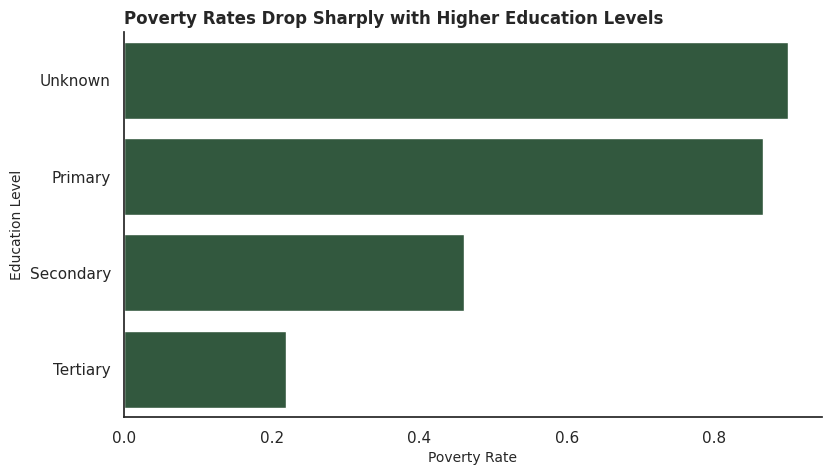

In [4]:
# Visual Storytelling
sns.set_theme(style='white')
plt.figure(figsize=(9,5))
economy_plot = economic_data.copy()
economy_plot['Education_Level'] = economy_plot['Education_Level'].fillna('Unknown')
edu_poverty = economy_plot.groupby(['Education_Level'])['Poverty_Status'].mean().sort_values(ascending=False).reset_index()

sns.barplot(data=edu_poverty, x='Poverty_Status', y='Education_Level', color='#2c5e3b')

sns.despine()
plt.title('Poverty Rates Drop Sharply with Higher Education Levels', fontsize=12, fontweight='bold', loc='left')
plt.xlabel('Poverty Rate', fontsize=10)
plt.ylabel('Education Level', fontsize=10)
plt.show()

**Phase 3: The Sealed Exam - Safe data Splitting**

- If the model sees the data before testing, it will memorize it

- We will split our data into 80%(Training tet or Study Guid)/20%(Test Set or Final Exam) for cleaning, scaling, standardization...to prevent data leakage

In [5]:
X = economic_data[['Age', 'Gender', 'Region', 'Location', 'Education_Level', 'Employment_Type']]
y = economic_data['Poverty_Status']

In [6]:
X.shape, y.shape

((10000, 6), (10000,))

In [7]:
# Split Our Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8000, 6), (2000, 6), (8000,), (2000,))

**Phase 4: Chaining factory - The ML Pipeline**

- Station 1(Imputer) - Fill in missing values with 'Unknown'

- Station 2(Encoder) - Translate categorical values into 1s & 0s

- Station 3(Scaler): Scale "Age" so it doesn't overpower other columns due to its larger numerical sizes

- Station 4(Random Forest): Gathers 100 decision trees to vote Democratically on the final prediction.

In [9]:
categorical_cols = ['Gender', 'Region', 'Location', 'Education_Level', 'Employment_Type']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('cat', categorical_transformer, categorical_cols),
    ('num', numerical_transformer, ['Age'])
])

poverty_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train the entire pipeline safely
poverty_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Region',
                                                   'Location',
                                                   'Education_Level',
                                                   'Employment_Type']),
                                                 ('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

**Phase 5: Business Risk Matrix Auditing**

- False alarms(False Positives: Wasted Government Funds) vs. Missed Targets(False Negatives: Families left starving)

- We must evaluate the ML Model's errors

- Decision: Safety nets; we maximize the safety net score

- Minimize missed targets, even if it causes a few false alarms

In [10]:
predictions = poverty_pipeline.predict(X_test)
print("\n--- Boardroom Confusion Risk Matrix ---")
print(confusion_matrix(y_test, predictions))
print("\n--- Model Performance Report ---")
print(classification_report(y_test, predictions, target_names=['Safe', 'In Poverty']))


--- Boardroom Confusion Risk Matrix ---
[[ 336  199]
 [ 167 1298]]

--- Model Performance Report ---
              precision    recall  f1-score   support

        Safe       0.67      0.63      0.65       535
  In Poverty       0.87      0.89      0.88      1465

    accuracy                           0.82      2000
   macro avg       0.77      0.76      0.76      2000
weighted avg       0.81      0.82      0.82      2000



In [24]:
# We built a Pipeline to prevent crashing
new_applicant = pd.DataFrame({'Age': [44],
                 'Gender': ['Female'],
                 'Region': ['North West'],
                 'Location': ['Urban'],
                 'Education_Level': ['Tertiary'],
                 'Employment_Type':['Wage-employed']})

In [25]:
new_applicant

,Age,Gender,Region,Location,Education_Level,Employment_Type
0,44,Female,North West,Urban,Tertiary,Wage-employed


In [26]:
print("Predicting the Status of One Applicant")
print(f"Model Grant Decision: {'APPROVE' if poverty_pipeline.predict(new_applicant) == 1 else 'DENY'}")

Predicting the Status of One Applicant
Model Grant Decision: DENY
